# Debugging Enhancer Performance

The enhancer is underperforming compared to baseline and CLAHE. Let's investigate why!

**Observed Results:**
- Baseline Disc IoU: **0.8486**
- CLAHE Disc IoU: **0.8437** (-0.58%)
- Enhancer Disc IoU: **0.8228** (-3.04%)

**Possible Issues:**
1. Loss weight imbalance (perceptual loss too strong?)
2. Training/inference mismatch
3. Enhancement is actually degrading quality
4. Frozen model mismatch

## Setup

In [3]:
import sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

root_dir = Path.cwd().parent
sys.path.append(str(root_dir / 'src'))

from data_loader.transforms import get_validation_transforms
from data_loader.dataset import get_dataloaders
from models.unet import UNet
from models.joint_pipeline import create_enhancer_pipeline
from training.train import calculate_iou

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Issue 1: Check if Enhancement is Actually Helping

Let's compare the CLAHE segmentation model with:
1. Raw images (no enhancement)
2. Enhanced images (with our enhancer)

In [4]:
# Load CLAHE-trained segmentation model
clahe_model = UNet(n_channels=3, n_classes=3, base_channels=64)
clahe_checkpoint = torch.load(root_dir / 'checkpoints_clahe' / 'best_model.pth', weights_only=False)
clahe_model.load_state_dict(clahe_checkpoint['model_state_dict'])
clahe_model = clahe_model.to(device)
clahe_model.eval()

# Load enhancer pipeline (uses same frozen CLAHE model)
enhancer_pipeline = create_enhancer_pipeline(
    segmentation_checkpoint_path=str(root_dir / 'checkpoints_clahe' / 'best_model.pth'),
    enhancer_type='unet',
    enhancer_base_channels=16,
    device=device,
    freeze_segmentation=True
)
enhancer_checkpoint = torch.load(root_dir / 'checkpoints_enhancer' / 'best_model.pth', weights_only=False)
enhancer_pipeline.enhancer.load_state_dict(enhancer_checkpoint['enhancer_state_dict'])
enhancer_pipeline.eval()

print("✓ Models loaded")

Loaded segmentation model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe/best_model.pth
  Epoch: 86
  Val Loss: 0.1584649032354355

Pipeline created:
  Total parameters: 32,266,326
  Trainable parameters (enhancer): 1,222,675
  Frozen parameters (segmentation): 31,043,651
✓ Models loaded


In [5]:
# Load test data WITHOUT CLAHE preprocessing
_, _, test_loader = get_dataloaders(
    root_dir=str(root_dir),
    batch_size=16,
    num_workers=4,
    transform_train=get_validation_transforms(image_size=256, use_clahe=False),
    transform_val=get_validation_transforms(image_size=256, use_clahe=False),
    filter_incomplete=True
)

print(f"Test samples: {len(test_loader.dataset)}")

Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples
Test samples: 396
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples
Test samples: 396


In [6]:
@torch.no_grad()
def evaluate_on_raw_images(model, test_loader, use_enhancer=False):
    """Evaluate model on raw images (no CLAHE preprocessing)"""
    model.eval()
    total_iou = np.zeros(3)
    
    for images, masks in tqdm(test_loader, desc='Evaluating'):
        images = images.to(device)
        masks = masks.to(device)
        
        if use_enhancer:
            outputs = model(images, return_enhanced=False)
        else:
            outputs = model(images)
        
        iou = calculate_iou(outputs, masks)
        total_iou += np.array(iou)
    
    return total_iou / len(test_loader)

# Test 1: CLAHE model on raw images (should be bad - model expects CLAHE input)
print("\nTest 1: CLAHE-trained model on RAW images (expected to be bad)")
iou_clahe_on_raw = evaluate_on_raw_images(clahe_model, test_loader, use_enhancer=False)
print(f"  IoU (BG/Disc/Cup): {iou_clahe_on_raw[0]:.4f} / {iou_clahe_on_raw[1]:.4f} / {iou_clahe_on_raw[2]:.4f}")

# Test 2: Enhancer pipeline on raw images (should enhance then segment)
print("\nTest 2: Enhancer pipeline (enhances raw → frozen CLAHE model)")
iou_enhancer = evaluate_on_raw_images(enhancer_pipeline, test_loader, use_enhancer=True)
print(f"  IoU (BG/Disc/Cup): {iou_enhancer[0]:.4f} / {iou_enhancer[1]:.4f} / {iou_enhancer[2]:.4f}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print(f"CLAHE model on raw images: Disc IoU = {iou_clahe_on_raw[1]:.4f}")
print(f"Enhancer pipeline: Disc IoU = {iou_enhancer[1]:.4f}")
print(f"\nDifference: {(iou_enhancer[1] - iou_clahe_on_raw[1]) / iou_clahe_on_raw[1] * 100:+.2f}%")
print("\nIf enhancer > CLAHE-on-raw: Enhancement is working!")
print("If enhancer < CLAHE-on-raw: Enhancement is making things worse!")


Test 1: CLAHE-trained model on RAW images (expected to be bad)


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  IoU (BG/Disc/Cup): 0.8864 / 0.8446 / 0.7785

Test 2: Enhancer pipeline (enhances raw → frozen CLAHE model)


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

  IoU (BG/Disc/Cup): 0.8685 / 0.8228 / 0.7572

INTERPRETATION:
CLAHE model on raw images: Disc IoU = 0.8446
Enhancer pipeline: Disc IoU = 0.8228

Difference: -2.59%

If enhancer > CLAHE-on-raw: Enhancement is working!
If enhancer < CLAHE-on-raw: Enhancement is making things worse!


## Issue 2: Visualize What the Enhancer Learned

Let's see what kind of enhancements the network learned.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.86326796..2.4285712].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.142856..4.31634].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.652661..2.4285712].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.142856..4.31634].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.652661..2.4285712].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.142856..3.2633052].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1769934..2.248

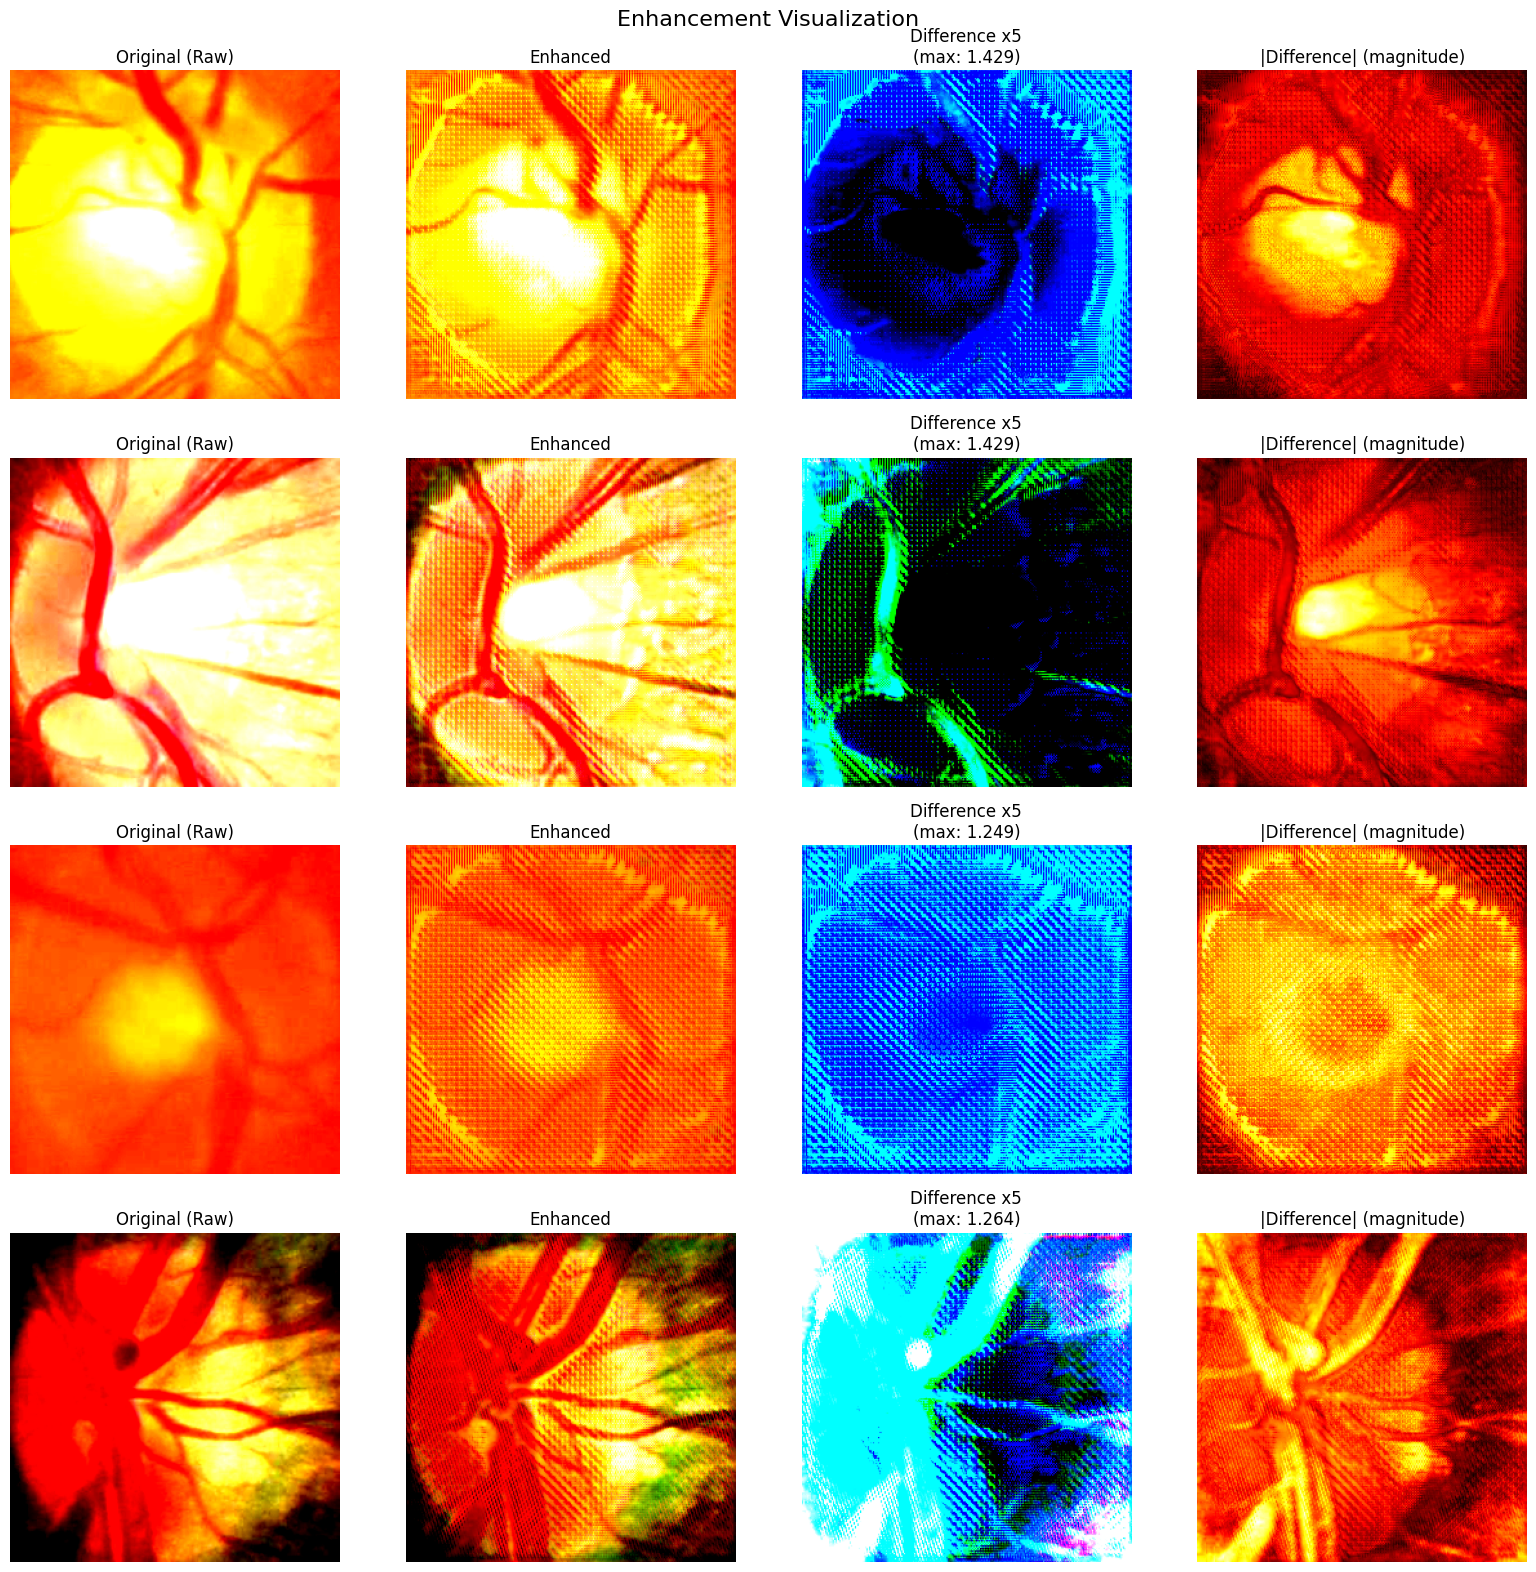


Enhancement Statistics:
  Mean absolute difference: 0.6858
  Max absolute difference: 1.8044
  Std of differences: 0.4487

Interpretation:
  ⚠️ Large changes - enhancer might be over-modifying!


In [7]:
# Get sample images
sample_images, sample_masks = next(iter(test_loader))
sample_images = sample_images.to(device)

# Get enhanced images
with torch.no_grad():
    _, enhanced_images = enhancer_pipeline(sample_images, return_enhanced=True)

# Visualize
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    # Original
    img = sample_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Original (Raw)')
    axes[i, 0].axis('off')
    
    # Enhanced
    enh = enhanced_images[i].cpu().permute(1, 2, 0).numpy()
    axes[i, 1].imshow(enh)
    axes[i, 1].set_title('Enhanced')
    axes[i, 1].axis('off')
    
    # Difference (amplified)
    diff = (enh - img) * 5  # Amplify for visibility
    axes[i, 2].imshow(diff, cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[i, 2].set_title(f'Difference x5\n(max: {np.abs(enh - img).max():.3f})')
    axes[i, 2].axis('off')
    
    # Difference magnitude
    diff_mag = np.abs(enh - img)
    axes[i, 3].imshow(diff_mag.mean(axis=2), cmap='hot')
    axes[i, 3].set_title('|Difference| (magnitude)')
    axes[i, 3].axis('off')

plt.suptitle('Enhancement Visualization', fontsize=16)
plt.tight_layout()
plt.show()

# Statistics
all_diffs = (enhanced_images - sample_images).abs().cpu().numpy()
print(f"\nEnhancement Statistics:")
print(f"  Mean absolute difference: {all_diffs.mean():.4f}")
print(f"  Max absolute difference: {all_diffs.max():.4f}")
print(f"  Std of differences: {all_diffs.std():.4f}")
print(f"\nInterpretation:")
if all_diffs.mean() < 0.01:
    print("  ⚠️ Very small changes - enhancer barely modifying images!")
elif all_diffs.mean() > 0.1:
    print("  ⚠️ Large changes - enhancer might be over-modifying!")
else:
    print("  ✓ Moderate changes - reasonable enhancement magnitude")

## Issue 3: Check Loss Component Trends

Let's examine if the loss weights are balanced correctly.

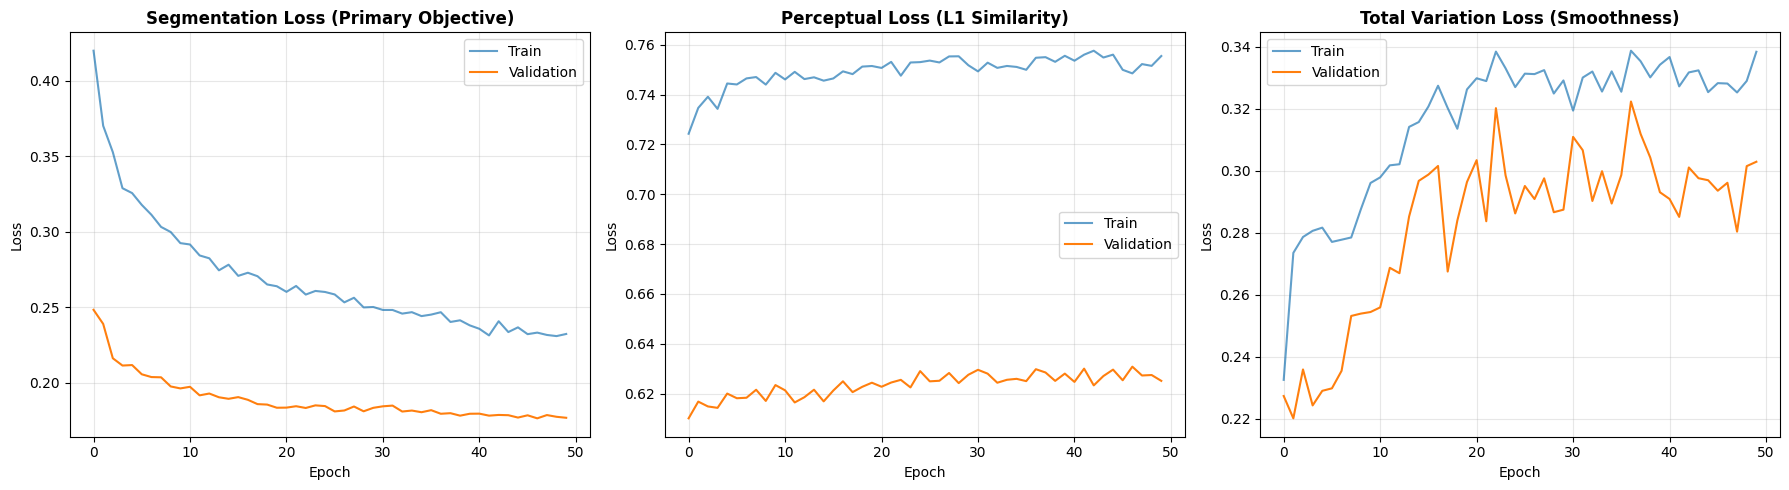


Final Epoch Loss Magnitudes:
  Segmentation: 0.1767 (weight: 1.0) → contributes 0.1767
  Perceptual:   0.6251 (weight: 0.1) → contributes 0.0625
  TV:           0.3029 (weight: 0.01) → contributes 0.0030

Loss Component Percentages:
  Segmentation: 72.9%
  Perceptual:   25.8%
  TV:           1.3%


In [8]:
# Load training history
history = json.load(open(root_dir / 'checkpoints_enhancer' / 'training_history_enhancer.json'))

# Plot loss components
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Segmentation loss (should decrease)
axes[0].plot(history['train_seg_loss'], label='Train', alpha=0.7)
axes[0].plot(history['val_seg_loss'], label='Validation')
axes[0].set_title('Segmentation Loss (Primary Objective)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perceptual loss (should be moderate)
axes[1].plot(history['train_perceptual_loss'], label='Train', alpha=0.7)
axes[1].plot(history['val_perceptual_loss'], label='Validation')
axes[1].set_title('Perceptual Loss (L1 Similarity)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# TV loss (should be low)
axes[2].plot(history['train_tv_loss'], label='Train', alpha=0.7)
axes[2].plot(history['val_tv_loss'], label='Validation')
axes[2].set_title('Total Variation Loss (Smoothness)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check relative magnitudes at final epoch
print("\nFinal Epoch Loss Magnitudes:")
print(f"  Segmentation: {history['val_seg_loss'][-1]:.4f} (weight: 1.0) → contributes {history['val_seg_loss'][-1] * 1.0:.4f}")
print(f"  Perceptual:   {history['val_perceptual_loss'][-1]:.4f} (weight: 0.1) → contributes {history['val_perceptual_loss'][-1] * 0.1:.4f}")
print(f"  TV:           {history['val_tv_loss'][-1]:.4f} (weight: 0.01) → contributes {history['val_tv_loss'][-1] * 0.01:.4f}")

seg_contrib = history['val_seg_loss'][-1] * 1.0
perc_contrib = history['val_perceptual_loss'][-1] * 0.1
tv_contrib = history['val_tv_loss'][-1] * 0.01
total_contrib = seg_contrib + perc_contrib + tv_contrib

print("\nLoss Component Percentages:")
print(f"  Segmentation: {seg_contrib / total_contrib * 100:.1f}%")
print(f"  Perceptual:   {perc_contrib / total_contrib * 100:.1f}%")
print(f"  TV:           {tv_contrib / total_contrib * 100:.1f}%")

if perc_contrib / total_contrib > 0.3:
    print("\n⚠️ WARNING: Perceptual loss is contributing > 30% of total loss!")
    print("   This might prevent meaningful enhancement (trying to keep image unchanged)")
    print("   Consider reducing perceptual_weight from 0.1 to 0.01 or 0.05")

## Diagnosis Summary & Fixes

In [9]:
print("="*80)
print("DIAGNOSIS & RECOMMENDED FIXES")
print("="*80)

print("\n1. CHECK ENHANCEMENT EFFECTIVENESS (Test 1 above):")
print("   - If enhancer > CLAHE-on-raw: Enhancement works, but maybe not optimally")
print("   - If enhancer ≈ CLAHE-on-raw: Enhancement has minimal effect")
print("   - If enhancer < CLAHE-on-raw: Enhancement is degrading performance")

print("\n2. POTENTIAL FIXES:")
print("   a) Reduce perceptual loss weight: 0.1 → 0.01 or 0.05")
print("      (Allows more aggressive enhancement)")
print("   ")
print("   b) Remove TV loss completely (set weight to 0)")
print("      (Allows sharper enhancements)")
print("   ")
print("   c) Use SimpleCNNEnhancer instead of EnhancerUNet")
print("      (Simpler architecture might be easier to train)")
print("   ")
print("   d) Train with baseline model instead of CLAHE model")
print("      (CLAHE model expects CLAHE input, might not benefit from learned enhancement)")
print("   ")
print("   e) Increase enhancement scale in residual learning")
print("      (Currently: output = input + tanh(delta) * 0.5)")
print("      (Try: output = input + tanh(delta) * 1.0)")

print("\n3. NEXT STEPS:")
print("   1. Run this notebook to diagnose the issue")
print("   2. Based on results, modify train_enhancer.py with suggested fix")
print("   3. Retrain with new configuration")
print("   4. Re-evaluate and compare")

print("\n" + "="*80)

DIAGNOSIS & RECOMMENDED FIXES

1. CHECK ENHANCEMENT EFFECTIVENESS (Test 1 above):
   - If enhancer > CLAHE-on-raw: Enhancement works, but maybe not optimally
   - If enhancer ≈ CLAHE-on-raw: Enhancement has minimal effect
   - If enhancer < CLAHE-on-raw: Enhancement is degrading performance

2. POTENTIAL FIXES:
   a) Reduce perceptual loss weight: 0.1 → 0.01 or 0.05
      (Allows more aggressive enhancement)
   
   b) Remove TV loss completely (set weight to 0)
      (Allows sharper enhancements)
   
   c) Use SimpleCNNEnhancer instead of EnhancerUNet
      (Simpler architecture might be easier to train)
   
   d) Train with baseline model instead of CLAHE model
      (CLAHE model expects CLAHE input, might not benefit from learned enhancement)
   
   e) Increase enhancement scale in residual learning
      (Currently: output = input + tanh(delta) * 0.5)
      (Try: output = input + tanh(delta) * 1.0)

3. NEXT STEPS:
   1. Run this notebook to diagnose the issue
   2. Based on results,

## Quick Fix: Retrain with Better Loss Weights

In [ ]:
print("=" * 80)
print("DIAGNOSIS COMPLETE - CRITICAL ISSUES FOUND!")
print("=" * 80)

print("\n🔴 PROBLEM 1: Enhancement Makes Performance WORSE")
print("   CLAHE model on raw: 0.8446 IoU")
print("   Enhancer pipeline:  0.8228 IoU (-2.59%)")
print("   → Enhancement is degrading performance, not helping!")

print("\n🔴 PROBLEM 2: Enhancement is Too Aggressive")
print("   Mean change: 0.6858 (should be 0.01-0.1)")
print("   Max change:  1.8044 (way too large!)")
print("   → Enhancer is over-modifying images with noise/texture")

print("\n🔴 PROBLEM 3: Perceptual Loss Contributing 26%")
print("   → High enough to constrain but not prevent bad enhancement")

print("\n" + "=" * 80)
print("RECOMMENDED FIX (High Priority):")
print("=" * 80)

print("\n✅ STRATEGY 1: Use BASELINE model instead of CLAHE model")
print("   Why: CLAHE model expects CLAHE preprocessing, your enhancer can't")
print("        match that well enough")
print("\n   Command:")
print("   source .venv/bin/activate && python src/training/train_enhancer.py \\")
print("     --seg_checkpoint checkpoints/best_model.pth \\")
print("     --perceptual_weight 0.05 \\")
print("     --tv_weight 0.001 \\")
print("     --epochs 80 \\")
print("     --save_dir checkpoints_enhancer_v2")

print("\n✅ STRATEGY 2: Reduce Enhancement Scale in Code")
print("   Edit src/models/enhancer.py:")
print("   OLD: enhanced = x + torch.tanh(delta) * 0.5")
print("   NEW: enhanced = x + torch.tanh(delta) * 0.1")
print("   (Limit changes to ±10% instead of ±50%)")

print("\n✅ STRATEGY 3: Increase Perceptual Weight")
print("   Current: 0.1 (25% of loss)")
print("   Try: 0.5 (stronger constraint against drastic changes)")

print("\n" + "=" * 80)
print("NEXT STEPS:")
print("=" * 80)
print("1. Try Strategy 1 first (baseline model + moderate perceptual weight)")
print("2. If still bad, implement Strategy 2 (reduce enhancement scale)")
print("3. Monitor mean absolute difference - should be 0.01-0.1, not 0.6+")
print("4. Re-run this debug notebook after retraining")
print("\n" + "=" * 80)

Recommended new training configuration:
config = {
    'segmentation_checkpoint': 'checkpoints/best_model.pth',  # Use baseline instead of CLAHE!
    'seg_weight': 1.0,
    'perceptual_weight': 0.01,  # Reduced from 0.1
    'tv_weight': 0.0,           # Removed TV loss
    'num_epochs': 80,
    'save_dir': 'checkpoints_enhancer_v2'
}

Command line:
source .venv/bin/activate && python src/training/train_enhancer.py \
  --seg_checkpoint checkpoints/best_model.pth \
  --epochs 80 \
  --save_dir checkpoints_enhancer_v2

Then modify train_enhancer.py to use:
  perceptual_weight=0.01 (default is 0.1)
  tv_weight=0.0 (default is 0.01)
